<a href="https://colab.research.google.com/github/sunkaravivek/ML-23CSE302/blob/main/lab-10/10.6_K_Means_Clustering-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

In [4]:
data = pd.read_csv('/content/geyser.csv')
print(data.head())

   duration  waiting   kind
0     3.600       79   long
1     1.800       54  short
2     3.333       74   long
3     2.283       62  short
4     4.533       85   long


In [5]:
print(data.columns)

Index(['duration', 'waiting', 'kind'], dtype='object')


In [6]:
data.columns = data.columns.str.strip().str.lower()

print(data.columns)

Index(['duration', 'waiting', 'kind'], dtype='object')


In [8]:
print(data.columns.tolist())

['duration', 'waiting', 'kind']


In [9]:
x = data.iloc[:, [0, 1]].values

print(x)

[[ 3.6   79.   ]
 [ 1.8   54.   ]
 [ 3.333 74.   ]
 [ 2.283 62.   ]
 [ 4.533 85.   ]
 [ 2.883 55.   ]
 [ 4.7   88.   ]
 [ 3.6   85.   ]
 [ 1.95  51.   ]
 [ 4.35  85.   ]
 [ 1.833 54.   ]
 [ 3.917 84.   ]
 [ 4.2   78.   ]
 [ 1.75  47.   ]
 [ 4.7   83.   ]
 [ 2.167 52.   ]
 [ 1.75  62.   ]
 [ 4.8   84.   ]
 [ 1.6   52.   ]
 [ 4.25  79.   ]
 [ 1.8   51.   ]
 [ 1.75  47.   ]
 [ 3.45  78.   ]
 [ 3.067 69.   ]
 [ 4.533 74.   ]
 [ 3.6   83.   ]
 [ 1.967 55.   ]
 [ 4.083 76.   ]
 [ 3.85  78.   ]
 [ 4.433 79.   ]
 [ 4.3   73.   ]
 [ 4.467 77.   ]
 [ 3.367 66.   ]
 [ 4.033 80.   ]
 [ 3.833 74.   ]
 [ 2.017 52.   ]
 [ 1.867 48.   ]
 [ 4.833 80.   ]
 [ 1.833 59.   ]
 [ 4.783 90.   ]
 [ 4.35  80.   ]
 [ 1.883 58.   ]
 [ 4.567 84.   ]
 [ 1.75  58.   ]
 [ 4.533 73.   ]
 [ 3.317 83.   ]
 [ 3.833 64.   ]
 [ 2.1   53.   ]
 [ 4.633 82.   ]
 [ 2.    59.   ]
 [ 4.8   75.   ]
 [ 4.716 90.   ]
 [ 1.833 54.   ]
 [ 4.833 80.   ]
 [ 1.733 54.   ]
 [ 4.883 83.   ]
 [ 3.717 71.   ]
 [ 1.667 64.   ]
 [ 4.567 77.  

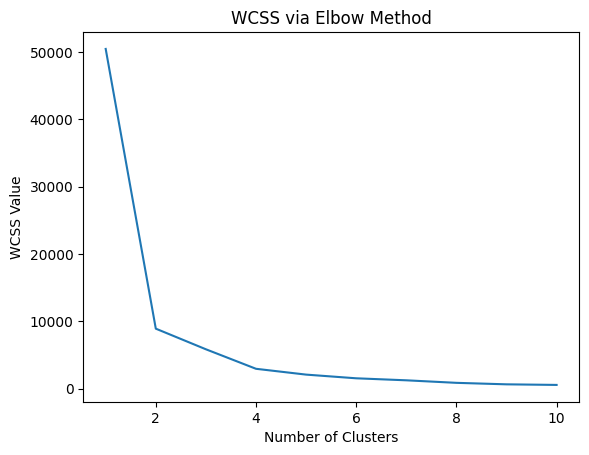

In [10]:
wcss = []

for i in range(1, 11):
    model = KMeans(n_clusters=i, init='k-means++', random_state=21)
    model.fit(x)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('WCSS via Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS Value')
plt.show()

In [11]:
model = KMeans(n_clusters=2, init='k-means++', random_state=42)

y_means = model.fit_predict(x)

print("Cluster labels:")
print(y_means)

Cluster labels:
[0 1 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1
 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0
 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0
 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 0 1
 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1
 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 0 1 0
 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 0 1 1 0 0 1 0 1 0]


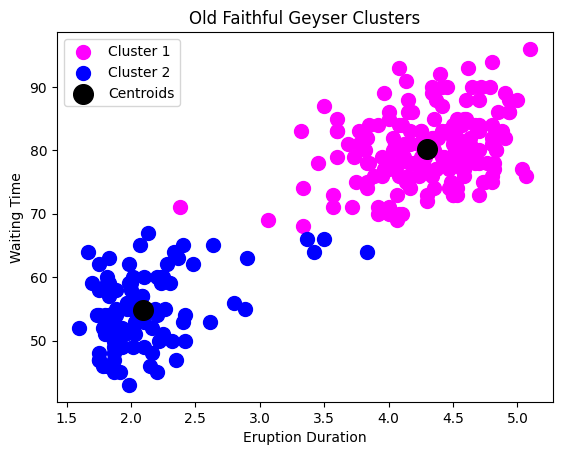

In [12]:
plt.scatter(x[y_means==0,0], x[y_means==0,1],
            s=100, c='magenta', label='Cluster 1')

plt.scatter(x[y_means==1,0], x[y_means==1,1],
            s=100, c='blue', label='Cluster 2')

plt.scatter(model.cluster_centers_[:,0],
            model.cluster_centers_[:,1],
            s=200, c='black', label='Centroids')

plt.title('Old Faithful Geyser Clusters')
plt.xlabel('Eruption Duration')
plt.ylabel('Waiting Time')
plt.legend()
plt.show()